In [1]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

from phd_helpers.helpers2 import (
    get_db_path, get_info_path, bone_pair_pose_intersection, get_mesh, get_info, remesh, avg_edge_length, get_motion_paths,
    get_edge_lengths
)


In [2]:
bones = np.array(['rad', 'uln', 'sca', 'lun', 'trq', 'pis', 'tpd',
                        'tpm', 'cap', 'ham', 'mc1', 'mc2', 'mc3', 'mc4', 'mc5'])

################# DATA #################
db_path = get_db_path()
info_path = get_info_path()
info = pd.read_csv(info_path)
cmc_info = info[info.group=='CMC']
stl_paths = cmc_info['path'].apply(lambda x: os.path.join(db_path, x)).values
n_bones = stl_paths.shape[0]

poses = np.array(['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral'])
bone_pairs = ['tpm-mc1', 'tpm-sca']
intersection_path = '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/KineticsData/FEA/checkInterference'
#intersection_path = r"C:\Users\scmo\OneDrive - University of Leeds\PhD-wrist\KineticsData\FEA\checkInterference"
safe_subjects = bone_pair_pose_intersection(bone_pairs, poses, intersection_path).values

safe_stl_paths = [x for x in stl_paths if f'{x.split("/")[-2]}{x.split("/")[-1][0]}' in safe_subjects]

stl_path = safe_stl_paths[0]
_, subject, _, sideL, _ = get_info(stl_path)
print(subject, sideL)
################# DATA #################

14548 R


# Smoothing - redo with smooth_taubin
- taubin keeps volume much much better than laplacian smoothing

## Laplacian

#### % based

In [ ]:
mesh = get_mesh(stl_paths[0], 'tpm')
vol = mesh.volume
L = mesh.length

rf = 0.01
it_end = 1000
it_step = 10
iters = np.arange(0, it_end+it_step, it_step)
d_vols = np.zeros(iters.shape[0])
d_Ls = np.zeros(iters.shape[0])
for i, its in enumerate(iters):

    mesh_smooth = mesh.smooth(n_iter=its, relaxation_factor=rf)
    vol_smooth = mesh_smooth.volume
    d_vols[i] = (1 - (vol_smooth / vol))*100
    d_Ls[i] = L - mesh_smooth.length

Length decrease: 0.4831


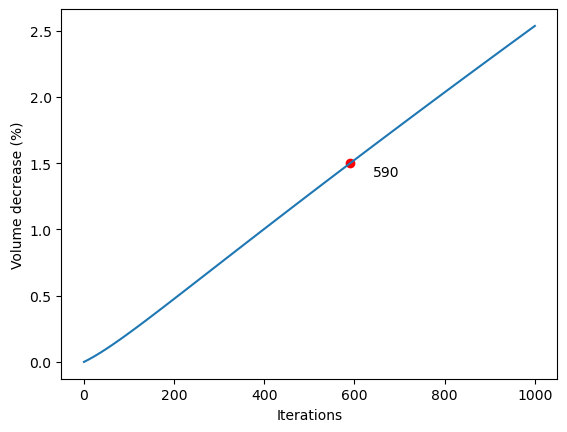

In [ ]:
# stl = 40
d_vol_limit = 1.5
max_iters = iters[d_vols<d_vol_limit][-1]
max_iters_idx = np.where(iters==max_iters)[0][0]
print(f'Length decrease: {d_Ls[max_iters_idx]:.4f}')

fig, ax  = plt.subplots()

ax.plot(iters, d_vols)
ax.scatter(max_iters, d_vols[max_iters_idx], color='red')

ax.set_xlabel('Iterations')
ax.set_ylabel('Volume decrease (%)')

ax.annotate(max_iters, [max_iters+50, d_vols[max_iters_idx]-0.1]);

Length decrease: 0.3323


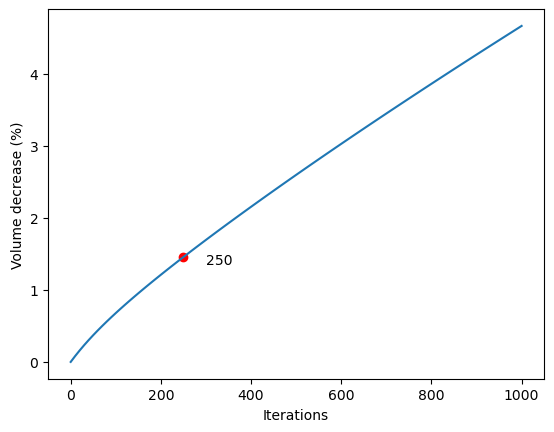

In [97]:
# stl = 0
d_vol_limit = 1.5
max_iters = iters[d_vols<d_vol_limit][-1]
max_iters_idx = np.where(iters==max_iters)[0][0]
print(f'Length decrease: {d_Ls[max_iters_idx]:.4f}')

fig, ax  = plt.subplots()

ax.plot(iters, d_vols)
ax.scatter(max_iters, d_vols[max_iters_idx], color='red')

ax.set_xlabel('Iterations')
ax.set_ylabel('Volume decrease (%)')

ax.annotate(max_iters, [max_iters+50, d_vols[max_iters_idx]-0.1]);

In [56]:
mesh.smooth(n_iter=max_iters).plot()

Widget(value='<iframe src="http://localhost:64443/index.html?ui=P_0x31ec6f500_6&reconnect=auto" class="pyvista…

In [111]:
d_vol_limit = 1
rf = 0.01
it_end = 1000
it_step = 10
iters = np.arange(0, it_end+it_step, it_step)

max_iters = np.zeros(len(stl_paths), dtype=int)
max_Ls = np.zeros(len(stl_paths))
for j, stl_path in tqdm(enumerate(stl_paths)):
    mesh = get_mesh(stl_path, 'tpm')
    vol = mesh.volume
    L = mesh.length

    d_vols = np.zeros(iters.shape[0])
    d_Ls = np.zeros(iters.shape[0])
    for i, its in enumerate(iters):

        mesh_smooth = mesh.smooth(n_iter=its, relaxation_factor=rf)
        vol_smooth = mesh_smooth.volume
        d_vols[i] = (1 - (vol_smooth / vol))*100
        d_Ls[i] = L - mesh_smooth.length


    max_iters[j] = iters[d_vols<d_vol_limit][-1]
    max_Ls[j] = d_Ls[d_vols<d_vol_limit][-1]

46it [03:21,  4.38s/it]


In [115]:
max_iters

array([150, 150, 210, 180, 100, 170, 140, 100, 180, 110, 130, 190, 110,
       100, 100, 140, 120, 130, 120, 160, 280, 240, 200, 240, 360, 250,
       280, 250, 270, 340, 280, 320, 290, 350, 290, 290, 290, 260, 210,
       340, 390, 360, 340, 340, 370, 360])

In [117]:
max_stl_idx = np.argmax(max_iters)
max_iter = np.max(max_iters)

min_stl_idx = np.argmin(max_iters)
min_iter = np.min(max_iters)

print(max_iter, min_iter)

390 100


In [123]:
mesh = get_mesh(stl_paths[max_stl_idx], 'tpm')

pl = pv.Plotter()
pl.add_mesh(mesh.smooth(n_iter=200))
#pl.add_mesh(mesh, style='wireframe', color='black')
pl.show()

Widget(value='<iframe src="http://localhost:64443/index.html?ui=P_0x3380a3bc0_25&reconnect=auto" class="pyvist…

In [120]:
mesh = get_mesh(stl_paths[min_stl_idx], 'tpm')

pl = pv.Plotter()
pl.add_mesh(mesh.smooth(n_iter=200))
#pl.add_mesh(mesh, style='wireframe', color='black')
pl.show()

Widget(value='<iframe src="http://localhost:64443/index.html?ui=P_0x338121f40_22&reconnect=auto" class="pyvist…

#### Fixed iterations

In [19]:
d_vol_limit = 1
rf = 0.01
its = 155

vols = np.zeros(stl_paths.shape[0])
d_vols = np.zeros(stl_paths.shape[0])
d_Ls = np.zeros(stl_paths.shape[0])
for i, stl_path in tqdm(enumerate(stl_paths)):
    mesh = get_mesh(stl_path, 'tpm')
    vol = mesh.volume
    L = mesh.length
    vols[i] = vol

    mesh_smooth = mesh.smooth(n_iter=its, relaxation_factor=rf)
    vol_smooth = mesh_smooth.volume
    d_vols[i] = (1 - (vol_smooth / vol))*100
    d_Ls[i] = L - mesh_smooth.length

46it [00:01, 42.65it/s]


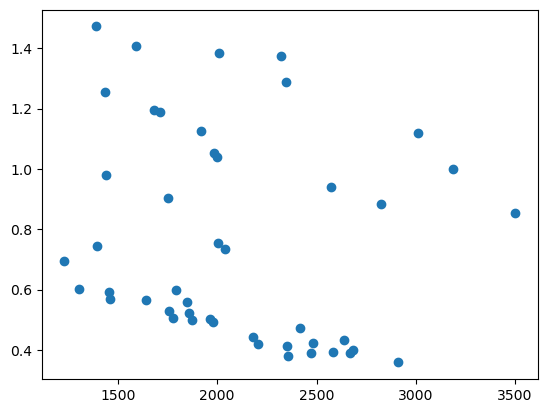

In [20]:
plt.scatter(vols, d_vols)

In [148]:
max_stl_idx = np.argmax(d_vols)
max_vol = np.max(d_vols)

min_stl_idx = np.argmin(d_vols)
min_vol = np.min(d_vols)

print(max_vol, min_vol)

1.4720870296689892 0.3582669454436749


In [158]:
mesh = get_mesh(stl_paths[max_stl_idx], 'tpm')

pl = pv.Plotter()
pl.add_mesh(mesh.smooth(n_iter=its))
#pl.add_mesh(mesh, style='wireframe', color='black')
pl.show()

Widget(value='<iframe src="http://localhost:64443/index.html?ui=P_0x31ec322a0_38&reconnect=auto" class="pyvist…

In [155]:
mesh = get_mesh(stl_paths[min_stl_idx], 'tpm')

pl = pv.Plotter()
pl.add_mesh(mesh.smooth(n_iter=its))
#pl.add_mesh(mesh, style='wireframe', color='black')
pl.show()

Widget(value='<iframe src="http://localhost:64443/index.html?ui=P_0x31ec7b170_35&reconnect=auto" class="pyvist…

#### Seems like its better to do fixed n_iter rather than look at volume?
 - cos all done with same image resolution? so all need same smoothing?

## Taubin

In [3]:
# Compare laplacian with taubin
mesh = get_mesh(stl_paths[0], 'tpm')
V_mesh = mesh.volume

# laplacian
n_lap = 250
mesh_lap = mesh.smooth(n_iter=n_lap)
V_lap = mesh_lap.volume

# taubin
n_tau = 50
mesh_tau = mesh.smooth_taubin(n_iter=n_tau)
V_tau = mesh_tau.volume

print(f'Laplacian volume change: {(1-(V_lap/V_mesh))*100:.2f}%')
print(f'Taubin volume change: {(1-(V_tau/V_mesh))*100:.2f}%')

pl = pv.Plotter()
pl.add_mesh(mesh_lap)
pl.add_text(f'Laplacian\ndV: {(1-(V_lap/V_mesh))*100:.2f}%', position='upper_right')
pl.show()
pl = pv.Plotter()
pl.add_mesh(mesh_tau)
pl.add_text(f'Taubin\ndV: {(1-(V_tau/V_mesh))*100:.2f}%', position='upper_right')
pl.show()

Laplacian volume change: 1.46%
Taubin volume change: 0.33%


Widget(value='<iframe src="http://localhost:60153/index.html?ui=P_0x1441c86b0_0&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:60153/index.html?ui=P_0x147914620_1&reconnect=auto" class="pyvista…

In [173]:
its = 50

vols = np.zeros(n_bones)
d_vols = np.zeros(n_bones)
d_Ls = np.zeros(n_bones)
n_cells = np.zeros(n_bones)
cell_avg_areas = np.zeros(n_bones)
cell_big_areas = np.zeros(n_bones)
cell_small_areas = np.zeros(n_bones)
cell_50_areas = np.zeros(n_bones)
edge_lengths = np.zeros(n_bones)
cell_angles = np.zeros(n_bones)
min_angles = np.zeros(n_bones)
cell_avg_rs = np.zeros(n_bones)
cell_10_rs = np.zeros(n_bones)
surface_areas = np.zeros(n_bones)
cell_ss = np.zeros(n_bones)
cell_shapes = np.zeros(n_bones)
for i, stl_path in tqdm(enumerate(stl_paths)):
    mesh = get_mesh(stl_path, 'tpm')
    if not mesh.is_manifold:
        print('Not manifold', stl_path)
    vol = mesh.volume
    L = mesh.length
    vols[i] = vol
    surface_areas[i] = mesh.area

    cells = mesh.n_cells
    n_cells[i] = mesh.n_cells
    cell_area = mesh.compute_cell_sizes().cell_data['Area']
    cell_avg_areas[i] = np.sum(cell_area) / cells
    q1, q3 = np.percentile(cell_area, [25, 75])
    cell_50_areas[i] = np.mean(cell_area[(cell_area >= q1) & (cell_area <= q3)])
    cell_big_areas[i] = np.percentile(cell_area, 95)
    cell_small_areas[i] = np.percentile(cell_area, 10)
    edge_lengths[i] = avg_edge_length(mesh)
    cell_angles[i] = np.percentile(mesh.cell_quality(['min_angle'])['min_angle'], 10)
    min_angles[i] = np.min(mesh.cell_quality(['min_angle'])['min_angle'])
    cell_10_rs[i] = np.percentile(mesh.cell_quality(['radius_ratio'])['radius_ratio'], 90)
    cell_avg_rs[i] = np.mean(mesh.cell_quality(['radius_ratio'])['radius_ratio'])
    cell_ss[i] = np.mean(mesh.cell_quality(['shape_and_size'])['shape_and_size'])
    cell_shapes[i] = np.mean(mesh.cell_quality(['shape'])['shape'])

    mesh_smooth = mesh.smooth_taubin(n_iter=its)
    vol_smooth = mesh_smooth.volume
    d_vols[i] = (1 - (vol_smooth / vol))*100
    d_Ls[i] = L - mesh_smooth.length

0it [00:00, ?it/s]

46it [00:01, 23.94it/s]


In [197]:
cmc_info.tpm_volume.idxmin()

np.int64(38)

In [176]:
cmc_info[d_vols > 0.1]

,group,subject,sex,age,side,path,tpm_volume
0,CMC,14548,F,25,R,CMC_Tasks/Young/Female/14548/RightSTL,1440.57
1,CMC,14613,M,52,R,CMC_Tasks/Old/Male/14613/RightSTL,3184.63
2,CMC,14685,F,23,R,CMC_Tasks/Young/Female/14685/RightSTL,2005.73
3,CMC,14726,M,48,R,CMC_Tasks/Old/Male/14726/RightSTL,3500.61
4,CMC,14727,F,47,R,CMC_Tasks/Old/Female/14727/RightSTL,2320.74
5,CMC,14818,F,24,R,CMC_Tasks/Young/Female/14818/RightSTL,1753.40
6,CMC,14819,M,25,R,CMC_Tasks/Young/Male/14819/RightSTL,1998.23
7,CMC,14827,F,20,L,CMC_Tasks/Young/Female/14827/LeftSTL,1388.37
8,CMC,14873,M,23,R,CMC_Tasks/Young/Male/14873/RightSTL,2823.84
9,CMC,14874,F,54,R,CMC_Tasks/Old/Female/14874/RightSTL,1437.32


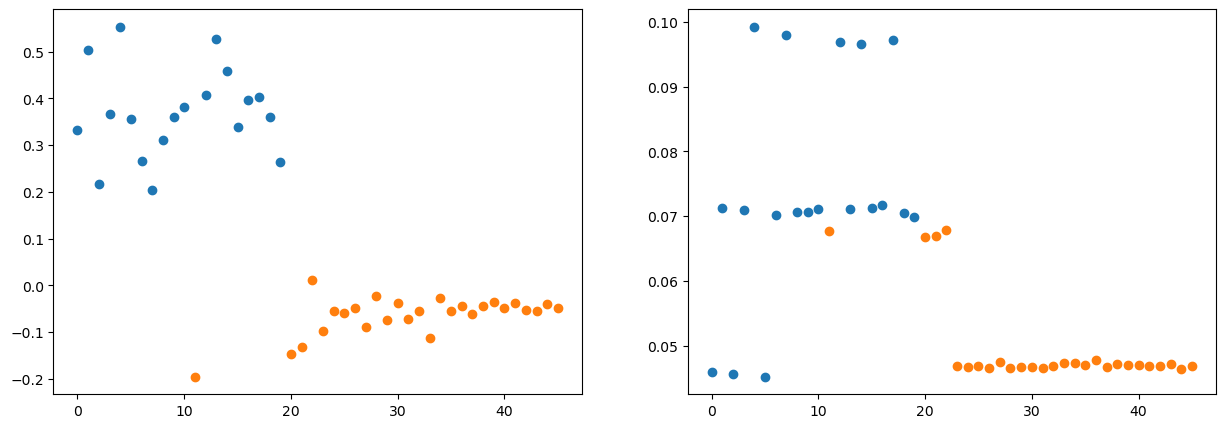

In [174]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

mask = d_vols > 0.1
mask007 = (~mask) & (cell_avg_areas > 0.06)
mask005 = mask & (cell_avg_areas < 0.06)
ax[0].scatter(np.arange(n_bones)[mask], d_vols[mask])
ax[0].scatter(np.arange(n_bones)[~mask], d_vols[~mask])

ax[1].scatter(np.arange(n_bones)[mask], cell_avg_areas[mask])
ax[1].scatter(np.arange(n_bones)[~mask], cell_avg_areas[~mask])

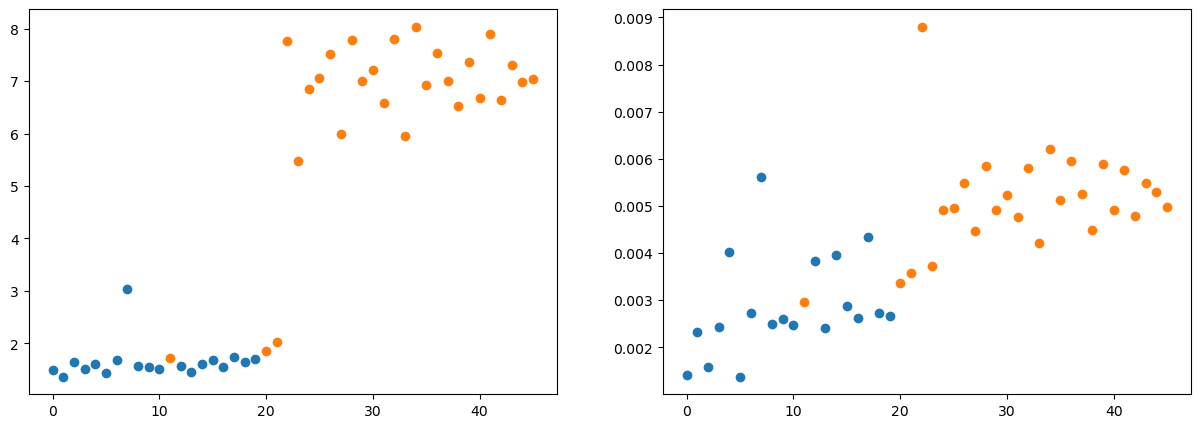

In [144]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(np.arange(n_bones)[mask], cell_angles[mask])
ax[0].scatter(np.arange(n_bones)[~mask], cell_angles[~mask])

ax[1].scatter(np.arange(n_bones)[mask], cell_small_areas[mask])
ax[1].scatter(np.arange(n_bones)[~mask], cell_small_areas[~mask])

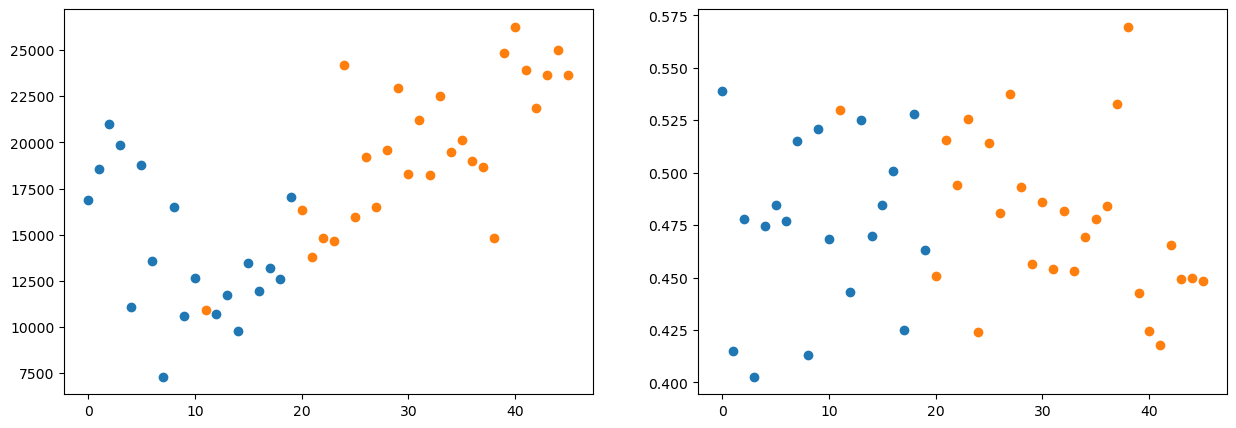

In [145]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(np.arange(n_bones)[mask], n_cells[mask])
ax[0].scatter(np.arange(n_bones)[~mask], n_cells[~mask])

ax[1].scatter(np.arange(n_bones)[mask], (surface_areas/vols)[mask])
ax[1].scatter(np.arange(n_bones)[~mask], (surface_areas/vols)[~mask])

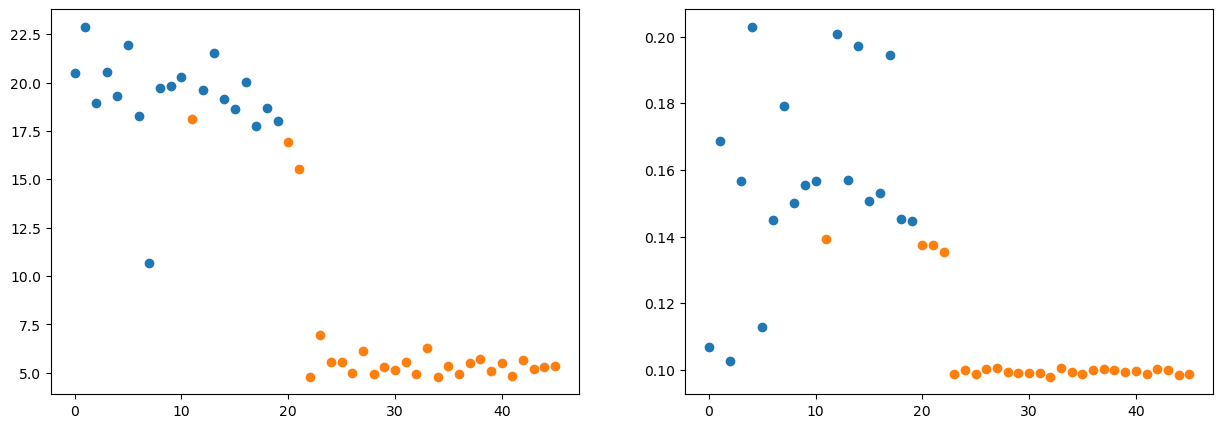

In [146]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(np.arange(n_bones)[mask], cell_10_rs[mask])
ax[0].scatter(np.arange(n_bones)[~mask], cell_10_rs[~mask])

ax[1].scatter(np.arange(n_bones)[mask], cell_big_areas[mask])
ax[1].scatter(np.arange(n_bones)[~mask], cell_big_areas[~mask])

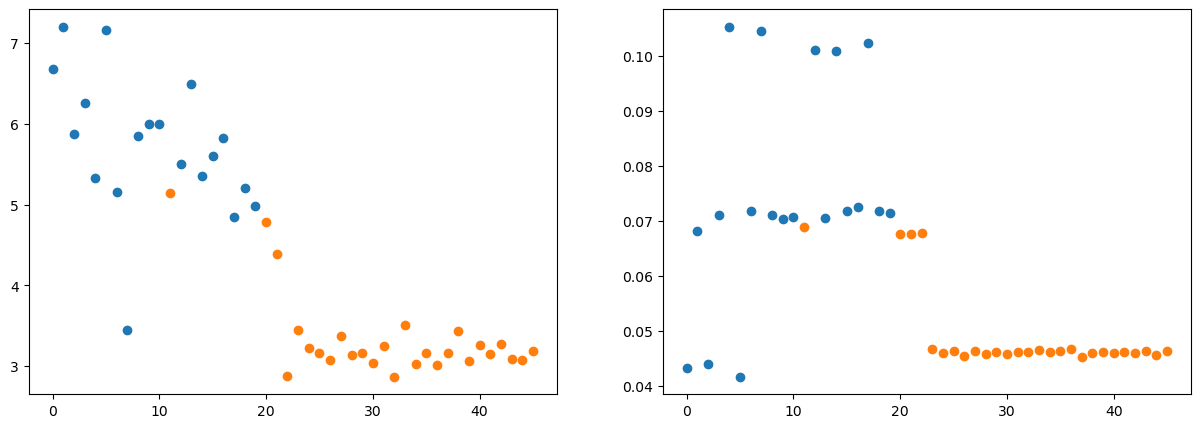

In [147]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(np.arange(n_bones)[mask], cell_avg_rs[mask])
ax[0].scatter(np.arange(n_bones)[~mask], cell_avg_rs[~mask])

ax[1].scatter(np.arange(n_bones)[mask], cell_50_areas[mask])
ax[1].scatter(np.arange(n_bones)[~mask], cell_50_areas[~mask])

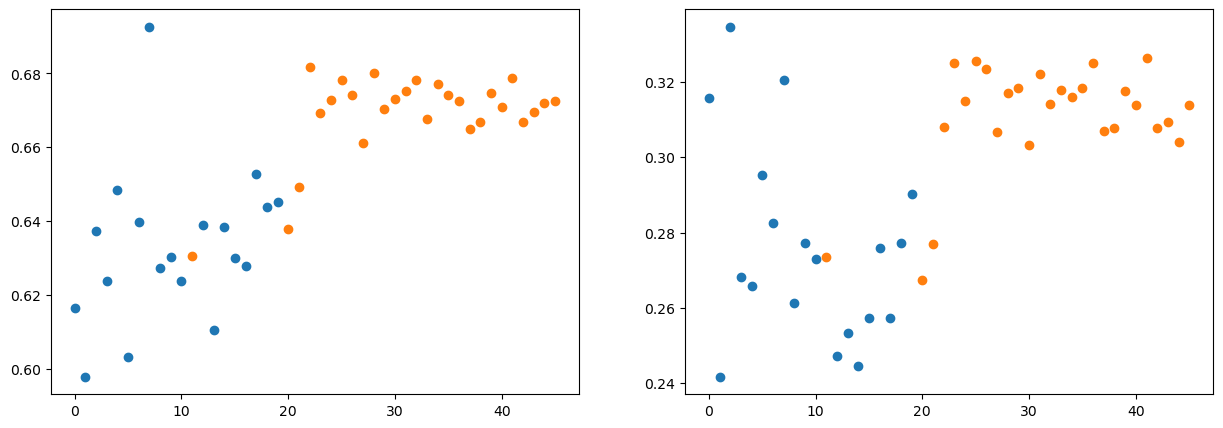

In [148]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(np.arange(n_bones)[mask], cell_shapes[mask])
ax[0].scatter(np.arange(n_bones)[~mask], cell_shapes[~mask])

ax[1].scatter(np.arange(n_bones)[mask], cell_ss[mask])
ax[1].scatter(np.arange(n_bones)[~mask], cell_ss[~mask])

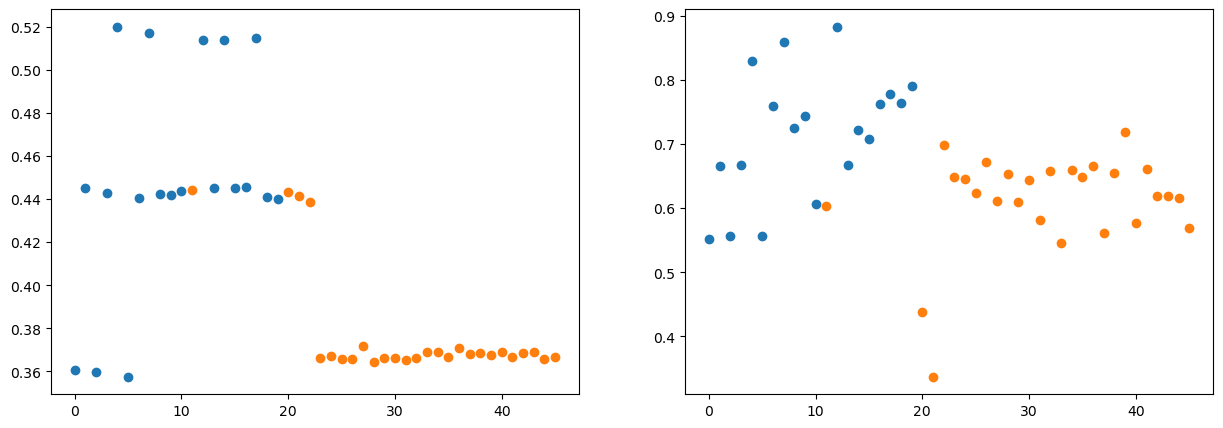

In [175]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].scatter(np.arange(n_bones)[mask], edge_lengths[mask])
ax[0].scatter(np.arange(n_bones)[~mask], edge_lengths[~mask])

ax[1].scatter(np.arange(n_bones)[mask], min_angles[mask])
ax[1].scatter(np.arange(n_bones)[~mask], min_angles[~mask])

### Find best explainers of the two groups

In [200]:
# get mesh quality measures

def get_metric_measures(metric):
    mean = np.mean(metric)
    low10, q1, median, q3, up10 = np.percentile(metric, [10, 25, 50, 75, 90])
    iqm = np.mean(metric[(metric >= q1) & (metric <= q3)])

    return {
        'mean':   mean, 
        'low10':  low10, 
        'q1':     q1, 
        'median': median, 
        'q3':     q3, 
        'up10':   up10, 
        'iqm':    iqm
    }
its = 50

metric_measures = {}
d_vols = np.zeros(n_bones)
lengths = np.zeros(n_bones)
for i, stl_path in tqdm(enumerate(stl_paths)):
    task, subject, side, sideL, _ = get_info(stl_path)
    metric_measures[subject] = {}

    # get mesh and volume
    mesh = get_mesh(stl_path, 'tpm')
    vol = mesh.volume
    lengths[i] = mesh.length

    # get mesh quality metrics
    quality = mesh.cell_quality([
                'area', 
                'aspect_frobenius',
                'aspect_ratio',
                'condition',
                'distortion',
                'max_angle',
                'min_angle',
                'radius_ratio',
                'relative_size_squared',
                'scaled_jacobian',
                'shape',
                'shape_and_size'
            ])
    # equiangle skew
    alphas = quality['min_angle']
    betas = quality['max_angle']
    quality['equiangle_skew'] = np.minimum(
        alphas / 60,
        (180 - betas) / (180 - 60)
    )
    edge_lengths = get_edge_lengths(mesh)

    # get metric values
    metric_measures[subject]['edge_length'] = get_metric_measures(edge_lengths)
    for name, metric in quality.cell_data.items():
        metric_measures[subject][name] = get_metric_measures(metric)


    # get volume change
    mesh_smooth = mesh.smooth_taubin(n_iter=its)
    vol_smooth = mesh_smooth.volume
    d_vols[i] = abs((1 - (vol_smooth / vol))*100)



46it [00:02, 20.70it/s]


In [201]:
# get df of metric measures indexed by subject
records = {}

for subject, metrics in metric_measures.items():
    flat = {}
    for metric_name, stats in metrics.items():
        for stat_name, value in stats.items():
            flat[f"{metric_name}_{stat_name}"] = value
    records[subject] = flat

df = pd.DataFrame.from_dict(records, orient="index")
df["volume_change_pct"] = d_vols
df["mesh_length"] = lengths
df.index.name = "subject"

<Axes: ylabel='volume_change_pct'>

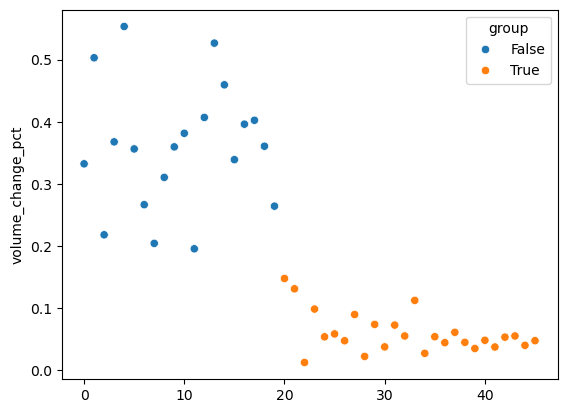

In [202]:
# divide into the two groups
from sklearn.mixture import GaussianMixture
import numpy as np

X = df["volume_change_pct"].values.reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=0)
labels = gmm.fit_predict(X)

df["group"] = labels
df['group'] = df['volume_change_pct'] < 0.17

# get masks of volume change and cell area groups
mask = df['group'].values.astype(bool)
mask005 = mask & (df['area_mean'] < 0.06)
mask007 = (~mask) & (df['area_mean']  > 0.06)

mask0 = mask & (~mask005) # group 0 and low cell area
mask1 = (~mask) & (~mask007) # group 1 and high cell area

# check groups
import seaborn as sns
sns.scatterplot(
    data=df,
    x=np.arange(n_bones),
    y="volume_change_pct",
    hue="group"
)

In [203]:
# Which single metric explains best

from scipy.stats import mannwhitneyu
import numpy as np

results = []

for col in df.columns:
    if col in ["volume_change_pct", "group"]:
        continue

    g0 = df.loc[df.group == 0, col]
    g1 = df.loc[df.group == 1, col]

    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    d = (g1.mean() - g0.mean()) / np.sqrt((g0.var() + g1.var()) / 2)

    results.append((col, abs(d), p))

univariate = (
    pd.DataFrame(results, columns=["metric", "effect_size", "p_value"])
      .sort_values("effect_size", ascending=False)
)
univariate.iloc[:10, :]

/var/folders/0j/j57rpcy571564618t2x0lw8c0000gn/T/ipykernel_16710/3943905657.py:16: RuntimeWarning: invalid value encountered in scalar divide
  d = (g1.mean() - g0.mean()) / np.sqrt((g0.var() + g1.var()) / 2)


,metric,effect_size,p_value
26,aspect_ratio_up10,4.874463,1.157916e-08
19,aspect_frobenius_up10,4.863589,1.157916e-08
33,condition_up10,4.863589,1.157916e-08
61,radius_ratio_up10,4.774738,1.157916e-08
78,shape_low10,4.560885,1.157916e-08
71,scaled_jacobian_low10,4.539412,1.157916e-08
50,min_angle_low10,4.536509,1.157916e-08
92,equiangle_skew_low10,4.536509,1.157916e-08
65,relative_size_squared_q1,4.186719,2.291278e-07
86,shape_and_size_q1,4.121740,1.420017e-07


In [134]:
# Which combination of metrics explains it best

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["volume_change_pct", "group"])
y = df["group"]

X_scaled = StandardScaler().fit_transform(X)

clf = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1
)
clf.fit(X_scaled, y)

coef = pd.Series(clf.coef_[0], index=X.columns)
important = coef[coef != 0].sort_values(key=np.abs, ascending=False)
important

max_angle_mean           0.417812
aspect_ratio_up10       -0.394717
condition_up10          -0.180691
aspect_frobenius_up10   -0.164049
dtype: float64

# Differences in absolute volume change can be explained by cell quality

In [194]:
mesh = get_mesh([x for x in stl_paths if '14827' in x][0], 'tpm')
mesh.plot(show_edges=True)
print(mesh.volume)

# outlier on min angle plot - has large areas of flat secions with good triangles
# which means min angle explains differences in absolute volume change

Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x37b683c80_21&reconnect=auto" class="pyvist…

1388.3670985799477


In [170]:
def plot_bad_cells(mesh, quality, metric, acceptable_ranges):
    unacceptable = quality.extract_values(scalars=metric, ranges=acceptable_ranges[metric], invert=True)
    print(metric)
    print('Bad cells = ', unacceptable.n_cells)

    if unacceptable.n_cells:
        pl = pv.Plotter()
        pl.add_mesh(mesh, style='wireframe', color='light gray')
        pl.add_mesh(unacceptable, color='lime')
        pl.view_xy()
        pl.camera.zoom(1.5)
        pl.show()

In [172]:
plot_bad_cells(mesh, mesh.cell_quality(['min_angle']), 'min_angle', {'min_angle':(21, np.inf)})

min_angle
Bad cells =  1816


Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x348d97dd0_20&reconnect=auto" class="pyvist…

In [205]:
(df['edge_length_mean'] / df['mesh_length']).sort_values()

subject
50001    0.009818
50061    0.009946
50053    0.010269
50034    0.010430
50037    0.010488
50090    0.010513
50049    0.010655
50020    0.010735
50045    0.010750
50016    0.010821
50007    0.011134
14818    0.011167
50014    0.011172
50018    0.011222
14685    0.011359
14613    0.011413
14726    0.011579
50024    0.011586
50021    0.011791
50029    0.011841
50017    0.011998
50019    0.012127
15737    0.012248
50027    0.012501
14873    0.012666
15882    0.012808
50006    0.012923
14548    0.012929
50008    0.013147
50033    0.013419
50000    0.013457
14819    0.013564
22306    0.013578
15358    0.013691
16276    0.013746
15294    0.014004
15441    0.014357
15006    0.014374
15283    0.014696
14727    0.015078
15357    0.015219
15284    0.015307
14874    0.015467
15282    0.015725
15285    0.016530
14827    0.019271
dtype: float64

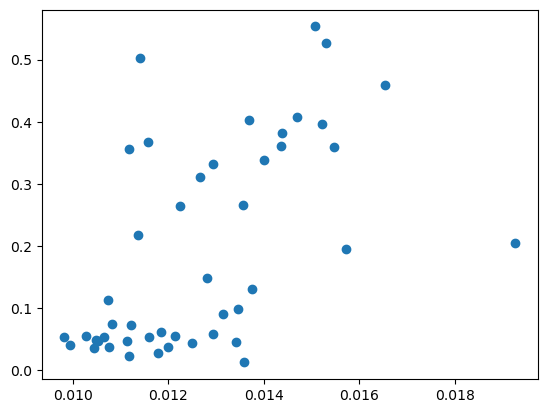

In [206]:
plt.scatter(df['edge_length_mean'] / df['mesh_length'], df['volume_change_pct'])

In [198]:
get_mesh(stl_paths[38], 'tpm').plot(show_edges=True)

Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x37b680140_22&reconnect=auto" class="pyvist…

In [164]:
get_mesh(stl_paths[16], 'tpm').plot(show_edges=True)

Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x34be02360_18&reconnect=auto" class="pyvist…

# Positive volume change = not so skinny triangles connecting nice looking cells - maybe have more triangles with two small angles and one slightly larger than 90?

# Negative volume change = very skinny triangles connecting nice looking cells - super skinny triangles have one tiny angle and the other two tend towards 90  ?

# still that just relates to cell quality, maybe just coincidence or likely related to some sublte methodology difference
# see further down for cell_quality correlations

# Absolute volume change explained by cell_quality (cos takes more to converge? - look into this***) - outlier on min_angle plot is the one with large flat areas (that lower max angle mean) - also has largest mean edge length to mesh length ratio.

<Axes: xlabel='max_angle_mean', ylabel='volume_change_pct'>

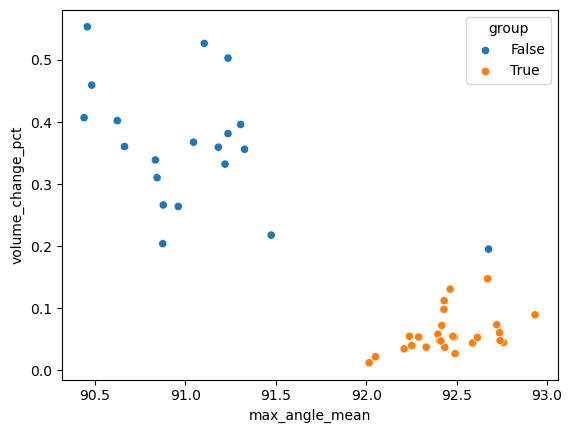

In [ ]:
import seaborn as sns
sns.scatterplot(
    data=df,
    x="max_angle_mean",
    y="volume_change_pct",
    hue="group"
)
# all on right are positive changes in volume and left are negative changes - resulting from some method difference?? 
# that shows up in max angle mean - in super skinny triangles two of the angles tend towards 90

<Axes: xlabel='min_angle_q1', ylabel='volume_change_pct'>

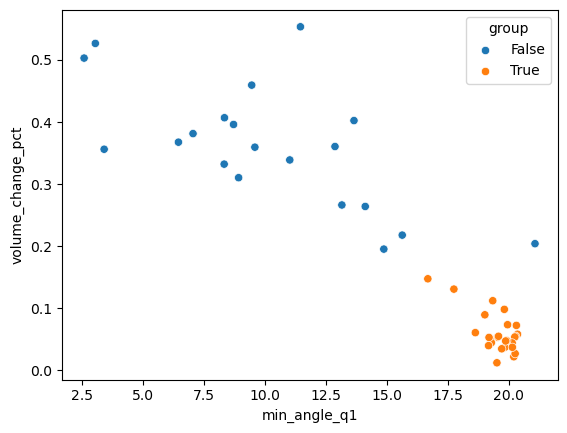

In [199]:
sns.scatterplot(
    data=df,
    x="min_angle_q1",
    y="volume_change_pct",
    hue="group"
)

<Axes: xlabel='relative_size_squared_mean', ylabel='volume_change_pct'>

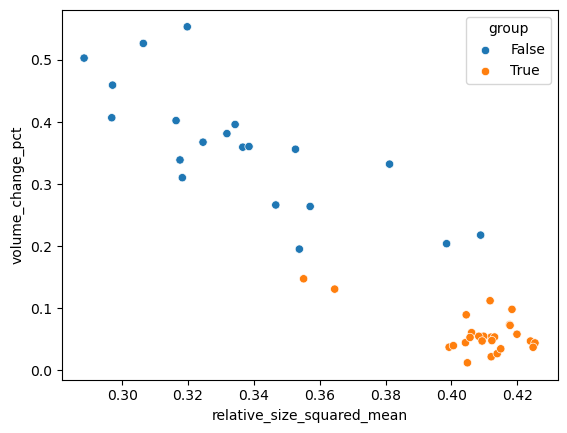

In [208]:
sns.scatterplot(
    data=df,
    x="relative_size_squared_mean",
    y="volume_change_pct",
    hue="group"
)

### Correlations

In [221]:
target = "volume_change_pct" 

X = df.select_dtypes("number").drop(columns=[target], errors="ignore")
# Pearson correlation of each column with target
corr = X.corrwith(df[target]).abs().sort_values(ascending=False)


/Users/matty/miniconda3/envs/wristrepair/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/matty/miniconda3/envs/wristrepair/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [222]:
corr[:25]

relative_size_squared_iqm       0.928137
relative_size_squared_q1        0.924369
relative_size_squared_mean      0.924171
aspect_ratio_up10               0.923727
radius_ratio_up10               0.923304
aspect_frobenius_up10           0.923052
condition_up10                  0.923052
aspect_frobenius_mean           0.922813
condition_mean                  0.922813
aspect_ratio_mean               0.921835
min_angle_q1                    0.912197
equiangle_skew_q1               0.912197
scaled_jacobian_q1              0.910718
shape_and_size_q1               0.910471
shape_q1                        0.901751
radius_ratio_mean               0.899687
shape_low10                     0.893171
scaled_jacobian_low10           0.892382
min_angle_low10                 0.892294
equiangle_skew_low10            0.892294
edge_length_low10               0.876841
max_angle_mean                  0.869627
relative_size_squared_low10     0.861203
relative_size_squared_median    0.833077
radius_ratio_med

<Axes: xlabel='condition_mean', ylabel='volume_change_pct'>

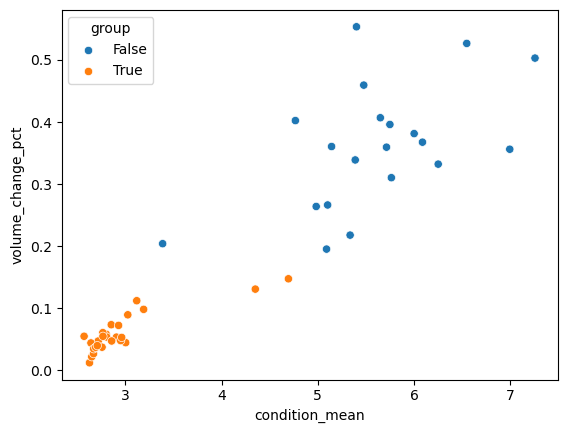

In [218]:
sns.scatterplot(
    data=df,
    x="condition_mean",
    y="volume_change_pct",
    hue="group"
)

# absolute volume change explained by cell quality
# signed change explained by mean_max angle but don't know why - assuming method differences

In [61]:
mesh = get_mesh(stl_paths[9], 'tpm').smooth_taubin(n_iter=50).plot()

Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x331c4ee10_9&reconnect=auto" class="pyvista…

In [62]:
mesh = get_mesh(stl_paths[30], 'tpm').smooth_taubin(n_iter=50).plot()

Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x331c4edb0_10&reconnect=auto" class="pyvist…

# Mesh quality

In [ ]:
def check_mesh_quality(mesh: pv.PolyData, metrics):

    quality = mesh.cell_quality(metrics)

    # equiangle skew
    alphas = quality['min_angle']
    betas = quality['max_angle']
    quality['equiangle_skew'] = np.minimum(
        alphas / 60,
        (180 - betas) / (180 - 60)
    )
    quality['radius_ratio'] = 1 / quality['radius_ratio']

    # remove any unwanted cell_data arrays
    for key in np.array(quality.cell_data.keys())[~np.isin(quality.cell_data.keys(), metrics + ['equiangle_skew'])]:
        quality.cell_data.remove(key)

    return quality

def plot_mesh_quality(quality, acceptable_ranges=None, worst_acceptable=None, bins=40, figsize=(20,10)):
    metrics = quality.cell_data.keys()
    
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        vals = quality[metric]
        ax = axes[i]

        # histogram
        ax.hist(vals, bins=bins, edgecolor='black', alpha=0.7)
        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)

        if acceptable_ranges and metric in acceptable_ranges:
            vmin, vmax = acceptable_ranges[metric]
            ax.axvspan(vmin, vmax, color='green', alpha=0.2, label='Acceptable range')
            ax.legend()

        # Plot worst acceptable threshold as red vertical line
        if worst_acceptable and metric in worst_acceptable:
            w = worst_acceptable[metric]
            ax.axvline(w, color='red', linestyle='--', linewidth=2, label="Worst acceptable")

    # Hide any empty axs
    for i in range(len(metrics), 8):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def mesh_quality_summary(quality, ideal_values, acceptable_ranges):
    rows = []
    for metric in ideal_values.keys():
        vals = quality[metric]
        ideal = ideal_values[metric]

        # distance from ideal
        dists = np.abs(vals - ideal)
        # closest to ideal
        best_val = vals[np.argmin(dists)]
        # furthest from ideal
        worst_val = vals[np.argmax(dists)]

        # % within threshold
        vmin, vmax = acceptable_ranges[metric]
        within = np.logical_and(vals >= vmin, vals <= vmax)
        pct_within = 100 * np.sum(within) / len(vals)

        # count outside the ideal range
        outside_count = len(vals) - np.sum(within)

        if worst_val < ideal:
            # worst below ideal = 5th pct
            pct_95 = np.round((np.percentile(vals, 5), best_val), 2)
        else:
            # worst above ideal  = 95th percentile
            pct_95 = np.round((best_val, np.percentile(vals, 95)), 2)

        rows.append({
            "metric": metric,
            "mean": vals.mean(),
            "best": best_val,
            "worst": worst_val,
            "acceptable_range": acceptable_ranges[metric],
            "acceptable_range_pct": pct_within,
            "bad_cells": outside_count,
            "95%": tuple(pct_95)
        })

    df = pd.DataFrame(rows)
    return df.set_index('metric')

def plot_bad_cells(mesh, quality, metric, acceptable_ranges):
    unacceptable = quality.extract_values(scalars=metric, ranges=acceptable_ranges[metric], invert=True)
    print(metric)
    print('Bad cells = ', unacceptable.n_cells)

    if unacceptable.n_cells:
        pl = pv.Plotter()
        pl.add_mesh(mesh, style='wireframe', color='light gray')
        pl.add_mesh(unacceptable, color='lime')
        pl.view_xy()
        pl.camera.zoom(1.5)
        pl.show()

In [113]:
mesh = get_mesh(stl_paths[0], 'tpm')

metrics = [
    "min_angle",
    "max_angle",
    "radius_ratio",
    "shape",
    "aspect_ratio",
    #"relative_size_squared",
    "scaled_jacobian",
]

acceptable_ranges = {
    'min_angle': (30, 60),
    'max_angle': (60, 120),
    'radius_ratio': (0.4, 1.0),
    'shape': (0.4, 1.0),
    'aspect_ratio': (1.0, 3.0),
    #'relative_size_squared': (0.4, 1),
    'scaled_jacobian': (0.5, 1.0),
    'equiangle_skew': (0.4, 1.0)
}

ideal_values = {
    'min_angle': 60,
    'max_angle': 60,
    'radius_ratio': 1.0,
    'shape': 1.0,
    'aspect_ratio': 1.0,
    #'relative_size_squared': 1.0,
    'scaled_jacobian': 1.0,
    'equiangle_skew': 1.0
}

worst_acceptable = {
    "min_angle": 30.0,
    "max_angle": 120.0,
    "radius_ratio": 0.4,
    "shape": 0.40,
    "aspect_ratio": 3.0,
    #"relative_size_squared": 0.4,
    "scaled_jacobian": 0.50,
    "equiangle_skew": 0.40
}

# missing ratio of traingle to equilateral triangle with same ascribed circle - but maybe shape does same thing

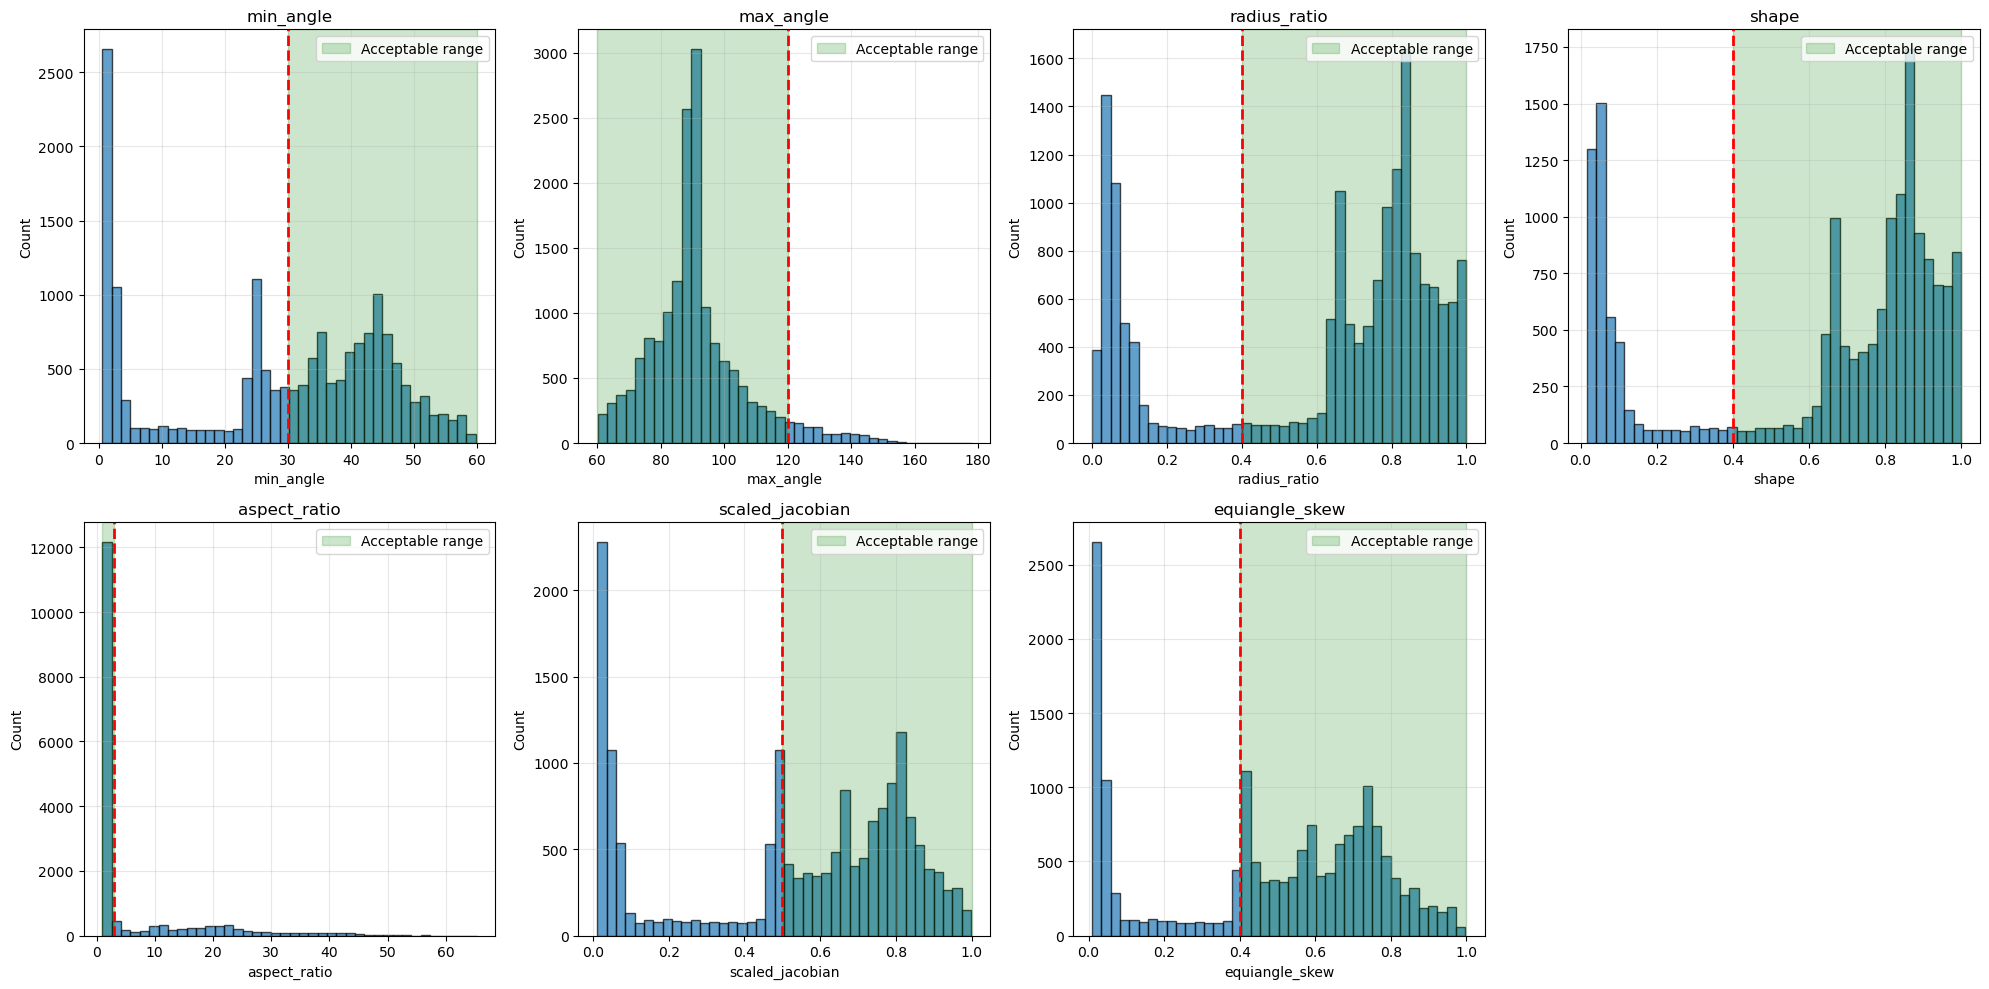

In [5]:
qual = check_mesh_quality(mesh, metrics)
summary_df = mesh_quality_summary(qual, ideal_values, acceptable_ranges)
plot_mesh_quality(qual, acceptable_ranges, worst_acceptable)

In [6]:
summary_df

,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,28.244701,59.843395,0.551410,"(30, 60)",53.466635,7866,"(1.09, 59.84)"
max_angle,91.219655,60.146979,177.974688,"(60, 120)",94.285376,966,"(60.15, 122.32)"
radius_ratio,0.601985,0.999990,0.000625,"(0.4, 1.0)",72.266919,4688,"(0.03, 1.0)"
shape,0.616492,0.999991,0.016667,"(0.4, 1.0)",72.681022,4618,"(0.03, 1.0)"
aspect_ratio,6.520166,1.001495,65.330925,"(1.0, 3.0)",72.947231,4573,"(1.0, 30.73)"
scaled_jacobian,0.522431,0.998418,0.011113,"(0.5, 1.0)",60.814009,6624,"(0.02, 1.0)"
equiangle_skew,0.470745,0.997390,0.009190,"(0.4, 1.0)",67.516564,5491,"(0.02, 1.0)"


In [7]:
its = 155
mesh_smooth = mesh.smooth(n_iter=its)
mesh_new = remesh(mesh_smooth, mesh.n_points, subs=3)

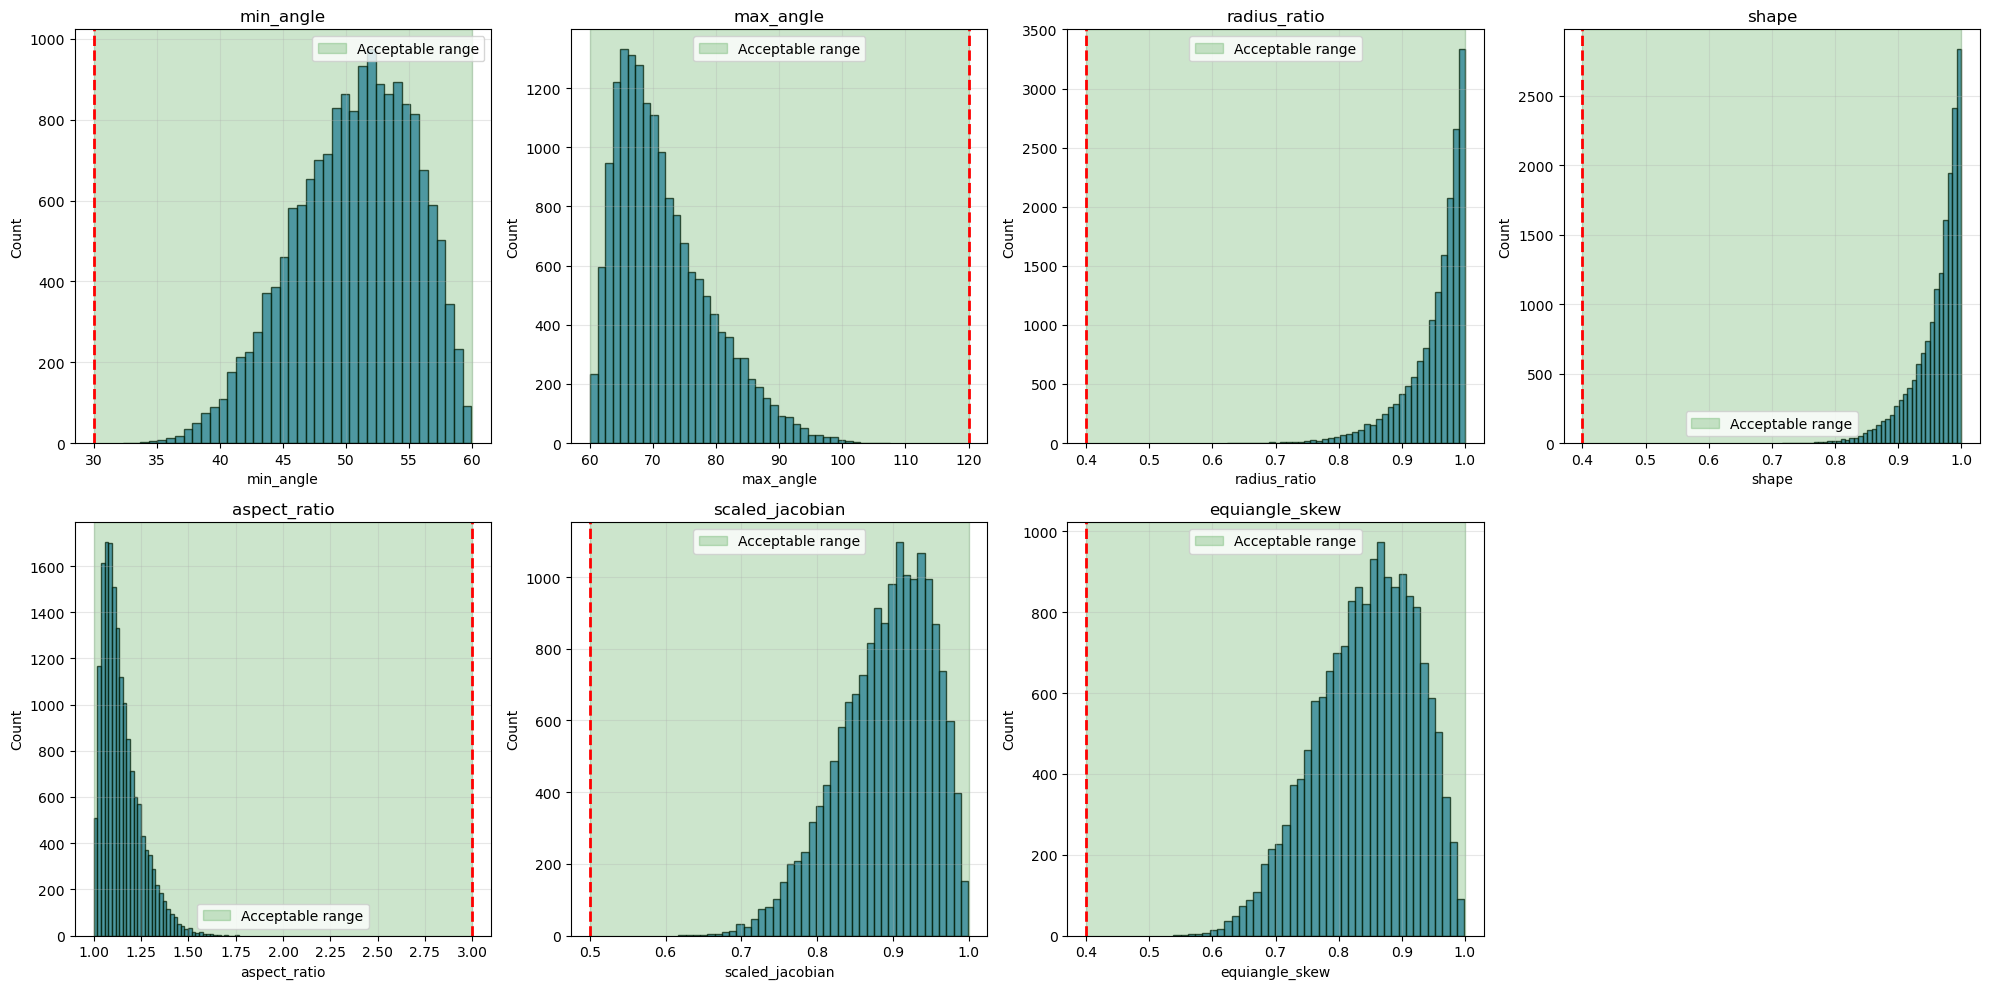

In [8]:
qual_new = check_mesh_quality(mesh_new, metrics)
summary_df = mesh_quality_summary(qual_new, ideal_values, acceptable_ranges)
plot_mesh_quality(qual_new, acceptable_ranges, worst_acceptable)

In [9]:
summary_df

,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,50.625546,59.930655,32.286264,"(30, 60)",100.0,0,"(42.11, 59.93)"
max_angle,71.671345,60.063608,107.593848,"(60, 120)",100.0,0,"(60.06, 86.4)"
radius_ratio,0.953770,0.999999,0.623086,"(0.4, 1.0)",100.0,0,"(0.86, 1.0)"
shape,0.960848,0.999999,0.716998,"(0.4, 1.0)",100.0,0,"(0.88, 1.0)"
aspect_ratio,1.144250,1.000642,1.766510,"(1.0, 3.0)",100.0,0,"(1.0, 1.35)"
scaled_jacobian,0.889601,0.999301,0.616783,"(0.5, 1.0)",100.0,0,"(0.77, 1.0)"
equiangle_skew,0.843759,0.998844,0.538104,"(0.4, 1.0)",100.0,0,"(0.7, 1.0)"


In [15]:
plot_bad_cells(mesh_new, qual_new, 'equiangle_skew', acceptable_ranges)

equiangle_skew
Bad cells =  0


In [11]:
print('Volume lost remeshing', round(100 - (mesh_new.volume / mesh_smooth.volume) * 100, 3), '%')

Volume lost remeshing 0.095 %


# Re-mesh with fixed boundary nodes

In [11]:
# get test saddle and boundary 
saddle_mesh_path = '/Users/matty/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/KineticsData/saddle-meshes2'
saddle_files = os.listdir(saddle_mesh_path)
saddle_files = [x for x in saddle_files if 'vtk' in x]
saddle_mesh_file = [x for x in saddle_files if subject in x and sideL in x][0]
saddle_mesh_path = os.path.join(saddle_mesh_path, saddle_mesh_file)
saddle_mesh = pv.read(saddle_mesh_path).extract_geometry()
saddle_mesh['saddle_id'] = np.arange(saddle_mesh.n_points)

In [12]:
npoints = int(saddle_mesh.n_points/2)
saddle_remesh = remesh(saddle_mesh, npoints=npoints)
boundary = saddle_mesh.extract_feature_edges(
                        boundary_edges=True, 
                        non_manifold_edges=False, 
                        feature_edges=False, 
                        manifold_edges=False
                        )
avg_edge_length(saddle_remesh)

np.float32(0.43685588)

In [8]:
saddle_remesh.plot(show_edges=True)

Widget(value='<iframe src="http://localhost:52152/index.html?ui=P_0x16bb804a0_0&reconnect=auto" class="pyvista…

In [9]:
save_path = f'/Users/matty/Documents/CPPremesh/CGALremesh/inputMesh/{subject}{sideL}saddle.stl'
saddle_remesh.save(save_path)

Now aim for edge length of 0.3 in CGAL in C++

In [35]:
saddle_cgal = pv.read(save_path.replace('input', 'output'))
boundary_cgal = saddle_cgal.extract_feature_edges(
                        boundary_edges=True, 
                        non_manifold_edges=False, 
                        feature_edges=False, 
                        manifold_edges=False
                        )
saddle_cgal.plot(show_edges=True)

Widget(value='<iframe src="http://localhost:52152/index.html?ui=P_0x31d3e3fb0_2&reconnect=auto" class="pyvista…

In [36]:
print(boundary.n_points)
print(boundary_cgal.n_points)

# to keep edge fixed need max_edge_length ≤ 4/3 * target_edge_length

124
364


# Remesh with region dependent density

In [5]:
from phd_helpers.ArticularGap import get_min_dfs

#### Get min_df

In [ ]:
poses = np.array(['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral'])
bone, ar_bone = 'tpm', 'mc1'
its = 155

mesh1 = get_mesh(stl_paths[0], bone)
bone_mesh = mesh1.smooth(n_iter=its)

mesh2 = get_mesh(stl_paths[0], ar_bone)
ar_mesh_neu = mesh2.smooth(n_iter=its)

motion_paths = get_motion_paths(stl_path)

min_df, _ = get_min_dfs(bone, ar_bone, bone_mesh, ar_mesh_neu, motion_paths, poses, max_gap=2) # set this to 3 to give buffer?

100%|██████████| 8/8 [00:10<00:00,  1.30s/it]


In [52]:
pl = pv.Plotter()

pl.add_mesh(bone_mesh, color='white')
pl.add_points(bone_mesh.points[min_df.bone_id])

pl.show()

Widget(value='<iframe src="http://localhost:58796/index.html?ui=P_0x309c581a0_4&reconnect=auto" class="pyvista…

# THIS ONE

#### Create points / edge_lengths csv

In [ ]:
bone_savepath = f'/Users/matty/Documents/CPPremesh/CGALremesh/SF-inputMesh/{subject}{sideL}-{bone}.obj'
fine_edge_length = 0.2
coarse_edge_length = 0.6
grad_width = 4 # width of edge lenth gradient region from fine to coarse

import gdist
bone_mesh.point_data['bone_id'] = np.arange(bone_mesh.n_points)
ar_mesh = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_geometry()
source_ids = ar_mesh.extract_feature_edges(
                        boundary_edges=True, 
                        non_manifold_edges=False, 
                        feature_edges=False, 
                        manifold_edges=False
                        ).point_data['bone_id']

dists = gdist.compute_gdist(
    bone_mesh.points.astype(np.float64),
    bone_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
    source_indices=source_ids.astype(np.int32),
)
not_ar_mask = ~np.isin(bone_mesh.point_data['bone_id'], min_df['bone_id'])
grad_mask = dists < grad_width
grad_ids = bone_mesh.point_data['bone_id'][not_ar_mask & grad_mask]
grad_dists = dists[not_ar_mask & grad_mask]

grad_edge_length = fine_edge_length + (grad_dists / grad_width) * (coarse_edge_length - fine_edge_length)

#df = pd.DataFrame(
#    {
#        'x': bone_mesh.points[:, 0],
#        'y': bone_mesh.points[:, 1],
#        'z': bone_mesh.points[:, 2],
#        'h': coarse_edge_length
#    }
#)
#df.loc[grad_ids, 'h'] = grad_edge_length
#df.loc[min_df['bone_id'], 'h'] = fine_edge_length

# save bone stl and edge_length csv
#df.to_csv(bone_savepath.replace('.obj', '.csv'), index=False)
#bone_mesh.save(bone_savepath)

bone_mesh['edge_length'] = np.full(bone_mesh.n_points, coarse_edge_length)
bone_mesh['edge_length'][grad_ids] = grad_edge_length
bone_mesh['edge_length'][min_df['bone_id']] = fine_edge_length

In [135]:
# verify edge lengths
bone_mesh.plot(scalars='edge_length')

Widget(value='<iframe src="http://localhost:58796/index.html?ui=P_0x30199e360_30&reconnect=auto" class="pyvist…

In [83]:
# Output csv of per vertex edge lengths

df = pd.Series(np.full(bone_mesh.n_points, coarse_edge_length))
df.iloc[grad_ids] = grad_edge_length
df.iloc[min_df['bone_id']] = fine_edge_length

df.to_csv(bone_savepath.replace('.obj', '.csv'), index=False, header=False)
bone_mesh.save(bone_savepath)

In [ ]:
bone = 'tpm'
bone_savepath = f'/Users/matty/Documents/CPPremesh/CGALremesh/inputMesh/{subject}{sideL}-{bone}.obj'

In [8]:
bone_remesh = pv.read(bone_savepath.replace('input', 'output'))
bone_remesh.plot(show_edges=True)

Widget(value='<iframe src="http://localhost:57212/index.html?ui=P_0x14bffea50_0&reconnect=auto" class="pyvista…

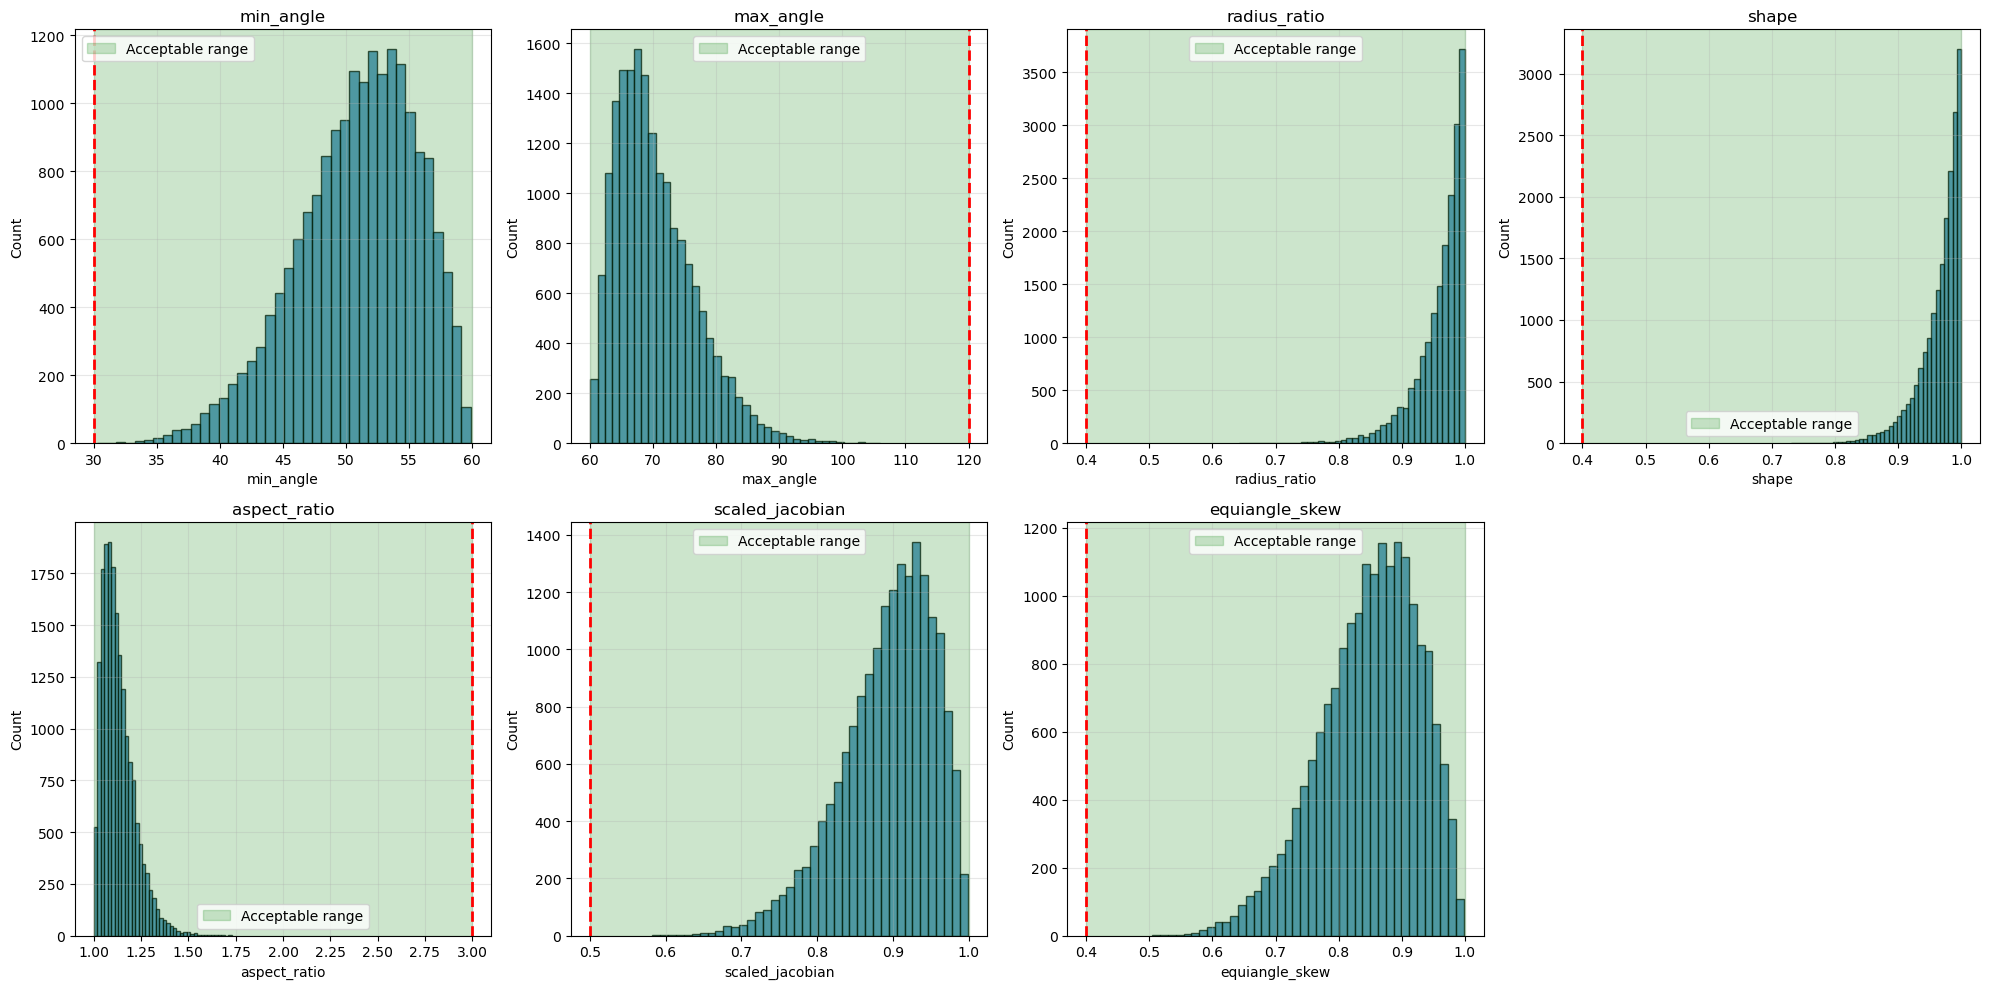

In [114]:
qual_remesh = check_mesh_quality(bone_remesh, metrics)
summary_df = mesh_quality_summary(qual_remesh, ideal_values, acceptable_ranges)
plot_mesh_quality(qual_remesh, acceptable_ranges, worst_acceptable)

In [116]:
summary_df

,mean,best,worst,acceptable_range,acceptable_range_pct,bad_cells,95%
metric,,,,,,,
min_angle,50.893813,59.880013,30.294194,"(30, 60)",100.0,0,"(42.17, 59.88)"
max_angle,70.378563,60.082391,105.945215,"(60, 120)",100.0,0,"(60.08, 82.4)"
radius_ratio,0.960694,0.999995,0.642475,"(0.4, 1.0)",100.0,0,"(0.88, 1.0)"
shape,0.965854,0.999996,0.730043,"(0.4, 1.0)",100.0,0,"(0.9, 1.0)"
aspect_ratio,1.128622,1.000834,1.728120,"(1.0, 3.0)",100.0,0,"(1.0, 1.29)"
scaled_jacobian,0.893010,0.998789,0.582477,"(0.5, 1.0)",100.0,0,"(0.78, 1.0)"
equiangle_skew,0.848230,0.998000,0.504903,"(0.4, 1.0)",100.0,0,"(0.7, 1.0)"


# END

In [234]:
from pathlib import Path
import pyvista as pv
subject, sideL = '14548', 'R'
bone, ar_bone = 'tpm', 'mc1'
output_path = Path(f'../MeshPrep/Meshes/{subject}{sideL}/{bone}-{ar_bone}')
remesh_file = f'{subject}{sideL}-{bone}.obj'
pv.read(output_path / remesh_file).plot(show_edges=True)

Widget(value='<iframe src="http://localhost:62801/index.html?ui=P_0x3834943e0_23&reconnect=auto" class="pyvist…

#### Convert to structured grid of values - didn't use

In [14]:
import pyvista as pv
print(pv.__version__)
print(hasattr(pv, "UniformGrid"))


0.46.3
False


In [ ]:
import csv
from scipy.spatial import cKDTree

# Grid resolution
NX = NY = NZ = np.ceil(np.mean(bone_mesh.points.max(axis=0) - bone_mesh.points.min(axis=0)) / avg_edge_length(bone_mesh)).astype(int)
POWER = 2.0      # IDW power
K = 8            # k nearest neighbours
H_MIN, H_MAX = 0.3, 0.5   # clamp range for edge length


def generate_grid(mesh, output_csv: str):

    if 'edge_length' not in mesh.point_data:
        raise ValueError("Mesh does not contain point array 'edge_length'")

    pts = mesh.points.astype(float)               # (N, 3)
    h_vals = np.asarray(mesh.point_data['edge_length'], dtype=float)  # (N,)

    # --- Bounding box from mesh vertices ---
    pmin = pts.min(axis=0) - 1
    pmax = pts.max(axis=0) + 1
    size = pmax - pmin

    # --- Regular grid definition ---
    xs = np.linspace(pmin[0], pmax[0], NX)
    ys = np.linspace(pmin[1], pmax[1], NY)
    zs = np.linspace(pmin[2], pmax[2], NZ)

    hx = xs[1] - xs[0] if NX > 1 else 1.0
    hy = ys[1] - ys[0] if NY > 1 else 1.0
    hz = zs[1] - zs[0] if NZ > 1 else 1.0

    # All grid points as (M, 3) array
    X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")
    grid_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

    # --- KD-tree on mesh vertices ---
    tree = cKDTree(pts)

    # Query K nearest neighbours for all grid points
    dists, idxs = tree.query(grid_points, k=K)
    # If K == 1, idxs and dists are 1D; make them 2D for uniform handling
    if K == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]

    # --- IDW interpolation (vectorised) ---
    # Avoid division by zero: if any distance == 0, we just take that vertex's h
    zero_mask = dists < 1e-12
    any_zero = zero_mask.any(axis=1)

    h_grid = np.empty(grid_points.shape[0], dtype=float)

    # Handle points with an exact match
    if any_zero.any():
        # index of first zero distance neighbour for each such point
        zero_idx = zero_mask.argmax(axis=1)
        h_grid[any_zero] = h_vals[idxs[any_zero, zero_idx]]

    # Handle the rest with standard IDW
    nonzero_mask = ~any_zero
    if nonzero_mask.any():
        d = dists[nonzero_mask]
        w = 1.0 / (d ** POWER)
        h_local = h_vals[idxs[nonzero_mask]]  # (M_nonzero, K)
        wsum = w.sum(axis=1)
        h_grid[nonzero_mask] = (w * h_local).sum(axis=1) / wsum

    # --- Clamp to a reasonable range ---
    h_grid = np.clip(h_grid, H_MIN, H_MAX)

    # --- Write CSV in the grid format ---
    with open(output_csv, "w", newline="") as f:
        w = csv.writer(f)

        # metadata: origin, spacing, dimensions
        w.writerow([xs[0], ys[0], zs[0]])
        w.writerow([hx, hy, hz])
        w.writerow([NX, NY, NZ])

        # write all grid nodes: x, y, z, h
        for (x, y, z), h in zip(grid_points, h_grid):
            w.writerow([float(x), float(y), float(z), float(h)])

    print(f"Grid CSV written to {output_csv}")
    print(f"h range in grid: {h_grid.min()} .. {h_grid.max()}")

output_csv = bone_savepath.replace('.obj', '_grid.csv')
generate_grid(bone_mesh, output_csv)


Grid CSV written to /Users/matty/Documents/CPPremesh/CGALremesh/inputMesh/14548R-tpm_grid.csv
h range in grid: 0.3 .. 0.5


##### 2id one - Create edge_length csv - face_id, region_id

In [77]:
bone_savepath = f'/Users/matty/Documents/CPPremesh/CGALremesh/inputMesh/{subject}{sideL}-{bone}_2id.obj'
dense_edge_length = 0.3
coarse_edge_length = 0.5

df = pd.DataFrame(
    {
        'face_id': np.arange(bone_mesh.n_cells),
        'region_id': 0 # coarse region id
    }
)

bone_mesh['bone_id'] = np.arange(bone_mesh.n_cells)
dense_face_ids = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_geometry()['bone_id']
df.loc[dense_face_ids, 'region_id'] = 1 # fine region id
df.region_id.value_counts()

region_id
0    13786
1     3118
Name: count, dtype: int64

In [78]:
df

,face_id,region_id
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
16899,16899,0
16900,16900,0
16901,16901,0
16902,16902,0


In [79]:
# save bone obj and edge_length csv
df.to_csv(bone_savepath.replace('.obj', '.csv'), index=False)
bone_mesh.save(bone_savepath)

In [80]:
pv.read(bone_savepath.replace('input', 'output')).plot(show_edges=True)

Widget(value='<iframe src="http://localhost:58796/index.html?ui=P_0x304796090_9&reconnect=auto" class="pyvista…

#### Trying with pygalmesh

 - Looks like remeshing functions aren't available in pygalmesh, only mesh generation stuff?

In [ ]:
import pygalmesh as cgal
import inspect
for name in dir(cgal):
    obj = getattr(cgal, name)
    if inspect.isclass(obj) or inspect.isfunction(obj):
        print(name)

Ball
Cone
Cuboid
Cylinder
Difference
DomainBase
Ellipsoid
Extrude
HalfSpace
Intersection
Polygon2D
RingExtrude
Rotate
Scale
Stretch
Tetrahedron
Torus
Translate
Union
generate_2d
generate_from_array
generate_from_inr
generate_mesh
generate_periodic_mesh
generate_surface_mesh
generate_volume_mesh_from_surface_mesh
remesh_surface
save_inr
